# <span style="color: #3498db;">1 Linear Equations in Linear Algebra</span>
（线性代数中的线性方程）

## 1.1 Systems of Linear Equations

线性方程形如$$a_{1}x_1+a_2x_2+...+a_nx_n=b$$
a和b为实数或者复数
多个包含相同变量的线性方程的组合被称为线性方程组，所有可能解的集合被称为解集，若两个线性方程组有相同的解集，称这两个线性方程组等价。


已知方程组
$$
\begin{cases}
x_1-2x_2+x_3=0 \\
2x_2-8x_3=8\\
5x_1-5x_3=10
\end{cases}
$$
其系数矩阵为
$$\begin{bmatrix} 1 & -2 & 1\\ 0 & 2 &-8\\5 & 0 &-5 \end{bmatrix}$$
其增广矩阵为$$\begin{bmatrix} 1 & -2 & 1 & 0\\ 0 & 2 &-8 & 8\\5 & 0 &-5 & 10\end{bmatrix}$$

基本行变换
1. (Replacement) Replace one row by the sum of itself and a multiple of another row.
2. (Interchange) Interchange two rows.
3. (Scaling) Multiply all entries in a row by a nonzero constant.

可利用行变换对增广矩阵进行化简，解方程组
如果两个线性方程组的增广矩阵等价，则他们有相同的解集


## 1.2 Row Reduction and Echelon Forms
一个矩阵为阶梯形（或行阶梯形）当且仅当它具有以下三个性质：
1. 所有非零行都位于全零行之上。
2. 每一行的首个非零元素位于其上方行的首个非零元素的右侧列中。
3. 列中位于主元下方的所有元素均为零。

简化阶梯形（行最简形）条件：
1. 非零行首项为1
2. 首项1是列中唯一非零元素

每个矩阵都与唯一一个行最简形等价。
矩阵可通过基本行变换化为行最简形，若该列非主元列（除最后一列），则该变量为自由变量。

唯一性定理
线性方程组相容（即有解）当且仅当增广矩阵的最右列不是主元列，也就是说，当且仅当增广矩阵的阶梯形形式中没有形如
$$\begin{bmatrix} 0 & 0 & ... & 0 & b\end{bmatrix} \text{b不为0}$$


### <span style="color: #3498db;">习题1.2 46
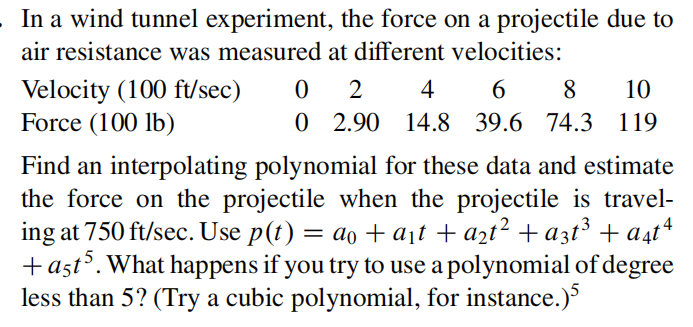

五次多项式插值的系数为:
[ 0.          9.7125     -9.528125    3.578125   -0.48671875  0.0234375 ]
五次多项式插值计算在750 ft/sec处的力为: 62.5825(1000lb)
即 6258.25 lb
三次多项式估计在750 ft/sec时的力为: 66.2551 (100 lb)
即 6625.51 lb



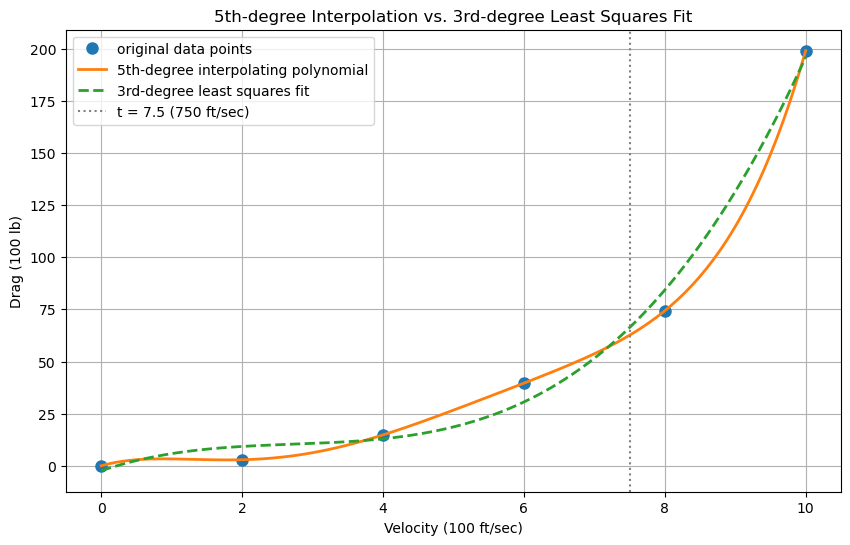

In [9]:
import numpy as np
import matplotlib.pyplot as plt

t=np.array([0, 2, 4, 6, 8, 10])
y=np.array([0, 2.9, 14.8, 39.6, 74.3, 199])

V=np.vander(t,increasing=True)
c5=np.linalg.solve(V,y)

print("五次多项式插值的系数为:")
print(c5)
p5=np.poly1d(c5[::-1])
t_target=7.5
force5=p5(t_target)
print(f"五次多项式插值计算在750 ft/sec处的力为: {force5:.4f}(1000lb)")
print(f"即 {force5 * 100:.2f} lb")

# 用3次多项式拟合
c3=np.polyfit(t, y, 3)
p3=np.poly1d(c3)

# 三次多项式在t=7.5处的估计
force3=p3(t_target)
print(f"三次多项式估计在750 ft/sec时的力为: {force3:.4f} (100 lb)")
print(f"即 {force3 * 100:.2f} lb")
print()

# 可视化比较
t_plot=np.linspace(0, 10, 200)
plt.figure(figsize=(10, 6))
plt.plot(t, y, 'o', label='original data points', markersize=8)
plt.plot(t_plot, p5(t_plot), label='5th-degree interpolating polynomial', linewidth=2)
plt.plot(t_plot, p3(t_plot), '--', label='3rd-degree least squares fit', linewidth=2)
plt.axvline(x=t_target, color='gray', linestyle=':', label=f't={t_target} (750 ft/sec)')
plt.xlabel('Velocity (100 ft/sec)')
plt.ylabel('Drag (100 lb)')
plt.legend()
plt.grid(True)
plt.title('5th-degree Interpolation vs. 3rd-degree Least Squares Fit')
plt.show()


由图可知三次多项式不能精确穿过所有点，且在t=7.5时计算出的偏差较大。

## 1.3 Vector Equations
n维列向量$\mathbb{R}^n$

$$
\mathbf{u}=
\begin{bmatrix}
u_1 \\
u_2 \\
\vdots \\
u_n
\end{bmatrix}
$$
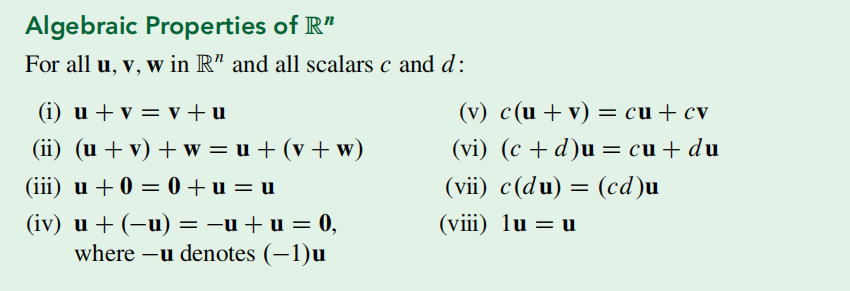

**线性组合的定义**

设 $\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_p$ 是 $\mathbb{R}^n$ 中的向量，$c_1, c_2, \dots, c_p$ 是任意实数（称为**标量**或**权重**）。则形如
$$
\mathbf{y}=c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots + c_p\mathbf{v}_p
$$
的向量称为向量 $\mathbf{v}_1, \dots, \mathbf{v}_p$ 的**线性组合**。

**张成空间的定义**

设 $\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_p$ 是 $\mathbb{R}^n$ 中的向量。则所有这些向量的**所有线性组合**的集合称为由 $\mathbf{v}_1, \dots, \mathbf{v}_p$ **张成**的 $\mathbb{R}^n$ 的子集，记为
$$
\operatorname{Span}\{\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_p\}.
$$
也就是说，$\operatorname{Span}\{\mathbf{v}_1, \dots, \mathbf{v}_p\}$ 是所有可以写成如下形式的向量 $\mathbf{y}$ 的集合：
$$
\mathbf{y}=c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots + c_p\mathbf{v}_p,
$$
其中 $c_1, c_2, \dots, c_p$ 是任意实数。

**b**在$\operatorname{Span}\{\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_p\}$中等价于向量方程
$$
c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots + c_p\mathbf{v}_p=\mathbf{b}
$$
有解


### <span style="color: #3498db;">习题1.3 35
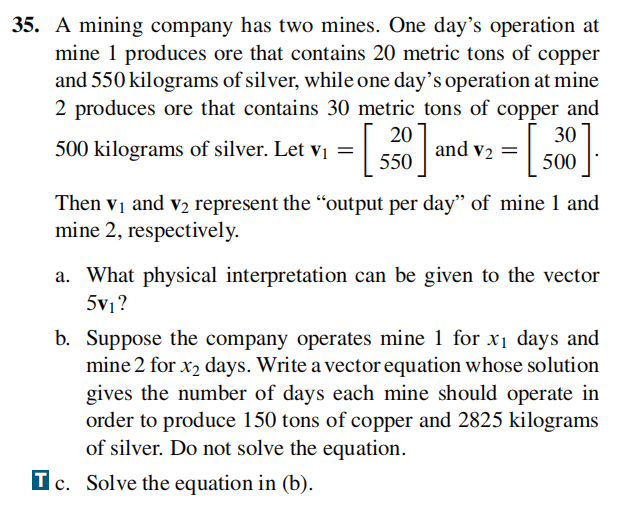

a. 物理意义为1号矿开采五天所生产的铜和银的总量。
$$5\mathbf{v}_1=5\begin{bmatrix} 20 \\550\end{bmatrix}=\begin{bmatrix} 100 \\2750\end{bmatrix}$$
即100吨铜和2750kg银。


b.设1号矿开采$x_{1}$天，2号矿开采$x_{2}$天，总产出为
$$x_{1}\mathbf{v}_1+x_{2}\mathbf{v}_2=\begin{bmatrix} 150 \\2825\end{bmatrix}$$
即$$x_{1}\begin{bmatrix} 20 \\550\end{bmatrix}+x_{2}\begin{bmatrix} 30 \\500\end{bmatrix}=\begin{bmatrix} 150 \\2825\end{bmatrix}$$


c.

In [12]:
import numpy as np

v1=np.array([20, 550])  
v2=np.array([30, 500]) 
b =np.array([150, 2825]) #目标产量

#构建系数矩阵A和右端向量b
A=np.column_stack((v1, v2))
x=np.linalg.solve(A, b)
print("35(b)的解:")
print(f"x1={x[0]:.4f}天(1号矿)")
print(f"x2={x[1]:.4f}天(2号矿)")
    
production=x[0]*v1 + x[1]*v2
print("\n验证产出:")
print(f"铜为{production[0]:.2f}吨 (目标 150)")
print(f"银为{production[1]:.2f}千克 (目标 2825)")

35(b)的解:
x1=1.5000天(1号矿)
x2=4.0000天(2号矿)

验证产出:
铜为150.00吨 (目标 150)
银为2825.00千克 (目标 2825)


### <span style="color: #3498db;">习题1.3 36
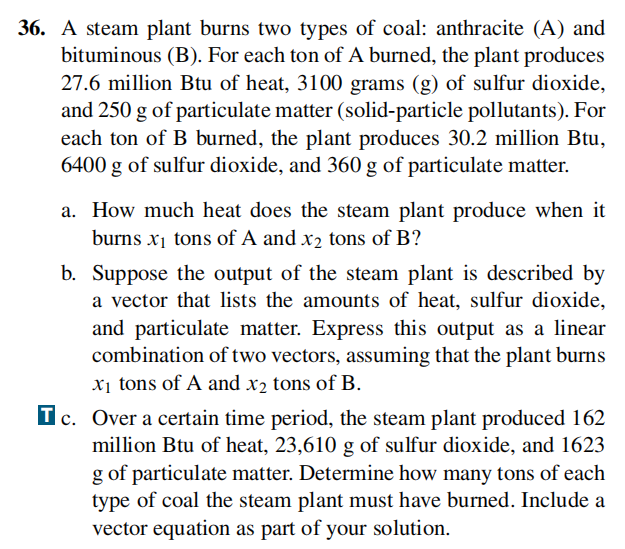

a. 当燃烧$x_1$吨A和$x_2$吨B时，产生的总热量P为：
$$P=27.6x_1 + 30.2x_2$$


b.
每吨 A 的产出：  
  $$ \mathbf{a} = \begin{bmatrix} 27.6 \\ 3100 \\ 250 \end{bmatrix}$$

每吨 B 的产出：  
  $$ \mathbf{b} = \begin{bmatrix} 30.2 \\ 6400 \\ 360 \end{bmatrix} $$

燃烧 $x_1$ 吨 A 和 $x_2$ 吨 B 的总产出向量为：

$$ \mathbf{y} = x_1\mathbf{a} + x_2\mathbf{b} =
x_1\begin{bmatrix} 27.6 \\ 3100 \\ 250 \end{bmatrix} +
x_2\begin{bmatrix} 30.2 \\ 6400 \\ 360 \end{bmatrix} $$

c.已知总产出为：

$$ \mathbf{y} = \begin{bmatrix} 162 \\ 23610 \\ 1623 \end{bmatrix} $$
求解向量方程：

$$ x_1\begin{bmatrix} 27.6 \\ 3100 \\ 250 \end{bmatrix} +
x_2\begin{bmatrix} 30.2 \\ 6400 \\ 360 \end{bmatrix} =
\begin{bmatrix} 162 \\ 23610 \\ 1623 \end{bmatrix} $$

即线性方程组：

$$ \begin{cases}
27.6x_1 + 30.2x_2 = 162 &  \\
3100x_1 + 6400x_2 = 23610 &  \\
250x_1 + 360x_2 = 1623 & 
\end{cases} $$

In [17]:
# 定义向量
a = np.array([27.6, 3100, 250])
b = np.array([30.2, 6400, 360])
y = np.array([162, 23610, 1623])

# 构造系数矩阵和右端向量
A = np.column_stack((a, b))
A2 = A[:2, :]   # 取前两行
y2 = y[:2]
x = np.linalg.solve(A2, y2)

print("解得：")
print(f"x1 = {x[0]:.6f} 吨 A")
print(f"x2 = {x[1]:.6f} 吨 B")
# 验证第三个方程
residual = A[2, 0]*x[0] + A[2, 1]*x[1] - y[2]
print(f"第三个方程（颗粒物）的残差：{residual:.2e} (接近于零，说明解是合理的)")

解得：
x1 = 3.900000 吨 A
x2 = 1.800000 吨 B
第三个方程（颗粒物）的残差：0.00e+00 (接近于零，说明解是合理的)


故答案为：A燃烧了3.9吨，B燃烧了1.8吨。

## 1.4 The Matrix Equation A**x** = **b**

$$ A\mathbf{x} = \begin{bmatrix} \mathbf{a}_1 & \mathbf{a}_2 & \cdots & \mathbf{a}_n \end{bmatrix} \begin{bmatrix} x_1\\x_2 \\ \cdots \\x_n \end{bmatrix} = x_1\mathbf{a}_1 + x_2\mathbf{a}_2 + \cdots + x_n\mathbf{a}_n $$

线性方程组A**x**=**b**有解，当且仅当**b**属于A的列空间。

设A是一$m \times n$的实矩阵，下面四个命题等价：

1.对于$\mathbb{R}^m$中的任意向量**b**，方程A**x**=**b**都有解；

2.$\mathbb{R}^m$中的向量**b**都是A的列向量的线性组合；

3.A的列向量张成整个$\mathbb{R}^m$空间；

4.A的每一行在主元列都有一个主元位置。



如果 $A$ 是一个 $m \times n$ 矩阵，$\mathbf{u}$ 和 $\mathbf{v}$ 是 $\mathbb{R}^n$ 中的向量，且 $c$ 是一个标量，则：

a. $A(\mathbf{u} + \mathbf{v}) = A\mathbf{u} + A\mathbf{v}$;

b. $A(c\mathbf{u}) = c(A\mathbf{u})$.

### <span style="color: #3498db;">习题1.4 47-50
![屏幕截图 2026-08-31 103729.png](<attachment:屏幕截图 2026-08-31 103729.png>)

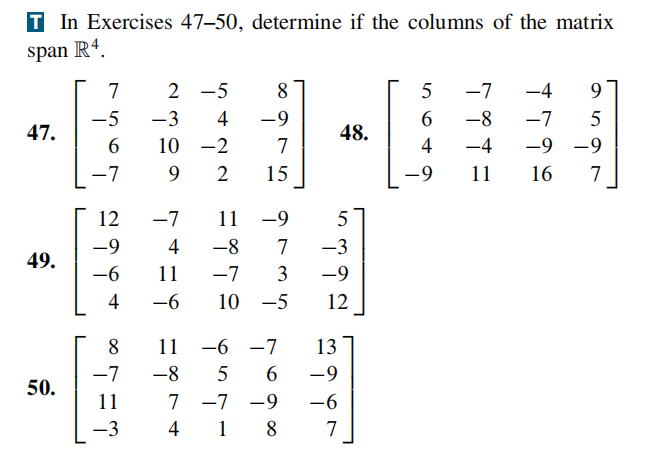

In [22]:
# 定义四个矩阵
matrices = {
    "47": np.array([
        [7, 2, -5, 8],
        [-5, -3, 4, -9],
        [6, 10, -2, 7],
        [-7, 9, 2, 15]
    ]),
    "48": np.array([
        [5, -7, -4, 9],
        [6, -8, -7, 5],
        [4, -4, -9, -9],
        [-9, 11, 16, 7]
    ]),
    "49": np.array([
        [12, -7, 11, -9, 5],
        [-9, 4, -8, 7, -3],
        [-6, 11, -7, 3, -9],
        [4, -6, 10, -5, 12]
    ]),
    "50": np.array([
        [8, 11, -6, -7, 13],
        [-7, -8, 5, 6, -9],
        [11, 7, -7, -9, -6],
        [-3, 4, 1, 8, 7]
    ])
}

# 矩阵的列向量张成R^4等价于矩阵的秩等于4
def check_span_r4(A):
    rank = np.linalg.matrix_rank(A)
    spans = rank == 4
    return rank, spans
print("     | Rank| Span R^4 |")
for key, A in matrices.items():
    rank, spans = check_span_r4(A)
    result = "Yes" if spans else "No"
    print(f"  {key} |  {rank}  |    {result}    |")

     | Rank| Span R^4 |
  47 |  3  |    No    |
  48 |  3  |    No    |
  49 |  4  |    Yes    |
  50 |  4  |    Yes    |


## 1.5 Solution Sets of Linear Systems

齐次线性方程组 $A\mathbf{x} = \mathbf{0}$ 有 **非平凡解**（即存在 $\mathbf{x} \neq \mathbf{0}$ 满足方程）的 **充要条件** 是：

> 该方程组在行化简后至少有一个 **自由变量**（即主元列数小于未知量个数 $n$）。

**定理（非齐次方程解的结构）**

假设方程 $A\mathbf{x} = \mathbf{b}$ 对某个给定的 $\mathbf{b}$ 是相容的（有解），并令 $\mathbf{p}$ 为其一个特解。则 $A\mathbf{x} = \mathbf{b}$ 的全部解集为所有形如  
$$
\mathbf{w} = \mathbf{p} + \mathbf{v}_h
$$
的向量，其中 $\mathbf{v}_h$ 是齐次方程 $A\mathbf{x} = \mathbf{0}$ 的任意解。

### <span style="color: #3498db;">习题1.5 37
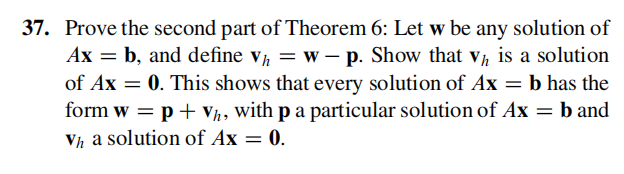

**37. 证明（定理6的第二部分）**

由题可知， $\mathbf{w}$ 是 $A\mathbf{x} = \mathbf{b}$ 的任意一个解，即  
$$
A\mathbf{w} = \mathbf{b}.
$$

$\mathbf{p}$ 是 $A\mathbf{x} = \mathbf{b}$ 的一个特解，因此  
$$
A\mathbf{p} = \mathbf{b}.
$$
若要证明 $\mathbf{v}_h$ 是齐次方程 $A\mathbf{x} = \mathbf{0}$ 的解，需证
$$
A\mathbf{v}_h = \mathbf{0}.
$$

又因为
$$
A\mathbf{v}_h = A(\mathbf{w} - \mathbf{p}) = A\mathbf{w} - A\mathbf{p}.
$$

将 $A\mathbf{w} = \mathbf{b}$ 和 $A\mathbf{p} = \mathbf{b}$ 代入上式：
$$
A\mathbf{v}_h = \mathbf{b} - \mathbf{b} = \mathbf{0}.
$$
所以 $\mathbf{v}_h$ 满足齐次方程 $A\mathbf{x} = \mathbf{0}$。

于是，由 $\mathbf{v}_h = \mathbf{w} - \mathbf{p}$ 可得  
$$
\mathbf{w} = \mathbf{p} + \mathbf{v}_h,
$$
其中 $\mathbf{p}$ 是 $A\mathbf{x} = \mathbf{b}$ 的一个特解，$\mathbf{v}_h$ 是 $A\mathbf{x} = \mathbf{0}$ 的一个解。

即证。


## 1.6 Applications of Linear Systems

实际问题可转化为线性方程组来解，所有模型都依赖于“总量是各部分之和”以及“按比例分配”的线性关系。

## 1.7 Linear Independence

如果向量方程  
$$
x_1\mathbf{v}_1 + x_2\mathbf{v}_2 + \cdots + x_p\mathbf{v}_p = \mathbf{0}
$$  
只有平凡解（零解），则$\mathbb{R}^n$ 中的一组向量 $\{\mathbf{v}_1, \ldots, \mathbf{v}_p\}$ 被称为**线性无关**。

如果存在不全为零的权重 $c_1, \ldots, c_p$，使得  
$$
c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots + c_p\mathbf{v}_p = \mathbf{0}
$$ 
集合 $\{\mathbf{v}_1, \ldots, \mathbf{v}_p\}$ 被称为**线性相关**的。 

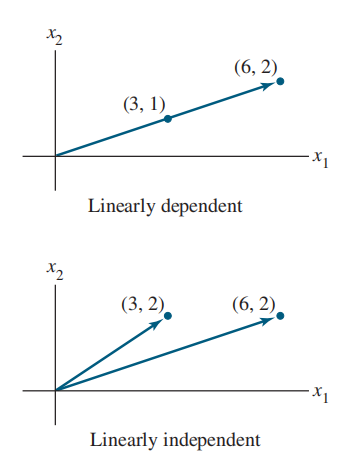

线性相关集合

包含两个或更多向量的集合 $S = \{\mathbf{v}_1, \ldots, \mathbf{v}_p\}$ 是线性相关的，当且仅当 $S$ 中至少有一个向量可以表示为其余向量的线性组合。如果 $S$ 线性相关且 $\mathbf{v}_1 \neq \mathbf{0}$，则存在某个 $\mathbf{v}_j$（其中 $j > 1$）可以表示为 $\mathbf{v}_1, \ldots, \mathbf{v}_{j-1}$ 的线性组合。

线性相关的一个充分条件

如果一个集合中的向量个数多于每个向量中的分量个数，则该集合线性相关。也就是说，$\mathbb{R}^n$ 中的任意集合 $\{\mathbf{v}_1, \ldots, \mathbf{v}_p\}$，若 $p > n$，则线性相关。

含有零向量的集合必线性相关

若 $\mathbb{R}^n$ 中的一个集合 $S = \{\mathbf{v}_1, \ldots, \mathbf{v}_p\}$ 含有零向量，则该集合线性相关。

### <span style="color: #3498db;">习题1.7 47 & 48
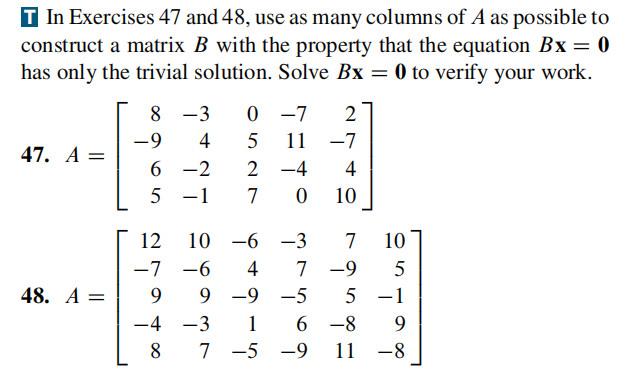


In [ ]:
from sympy import Matrix, symbols, solve

# 习题47
A47 = np.array([
    [8, -3, 0, -7, 2],
    [-9, 4, 5, 11, -7],
    [6, -2, 2, -4, 4],
    [5, -1, 7, 0, 10]
])

# 找出主元列
A47_sym = Matrix(A47)
rref47, pivot_cols47 = A47_sym.rref()
print("A47的行最简形：")
print(rref47)
print(f"主元列索引: {pivot_cols47}")

# 构造B：使用主元列对应的列
B47 = A47[:, pivot_cols47]
print("\nB47 =")
print(B47)

# 验证Bx = 0只有平凡解
B47_sym = Matrix(B47)
rank_B47 = B47_sym.rank()
print(f"\nB47的秩: {rank_B47}")
print(f"B47的列数: {B47.shape[1]}")
if rank_B47 == B47.shape[1]:
    print("列满秩，因此Bx = 0只有平凡解。")
else:
    print("列不满秩，存在非零解。")

# 求解Bx = 0验证
nullspace_B47 = B47_sym.nullspace()
print(f"零空间维数: {len(nullspace_B47)}")
if len(nullspace_B47) == 0:
    print("零空间只有零向量，结果正确。")
else:
    print("零空间基向量:")
    for v in nullspace_B47:
        print(v)

A47的行最简形：
Matrix([[1, 0, 3, 1, 0], [0, 1, 8, 5, 0], [0, 0, 0, 0, 1], [0, 0, 0, 0, 0]])
主元列索引: (0, 1, 4)

B47 =
[[ 8 -3  2]
 [-9  4 -7]
 [ 6 -2  4]
 [ 5 -1 10]]

B47的秩: 3
B47的列数: 3
列满秩，因此Bx = 0只有平凡解。
零空间维数: 0
零空间只有零向量，结果正确。


In [31]:
# 习题48
A48 = np.array([
    [12, 10, -6, -3, 7, 10],
    [-7, -6, 4, 7, -9, 5],
    [9, 9, -9, -5, 5, -1],
    [-4, -3, 1, 6, -8, 9],
    [8, 7, -5, -9, 11, -8]
])

A48_sym = Matrix(A48)
rref48, pivot_cols48 = A48_sym.rref()
print("A48的行最简形：")
print(rref48)
print(f"主元列索引: {pivot_cols48}")

# 构造B
B48 = A48[:, pivot_cols48]
print("\nB48 =")
print(B48)

# 验证Bx = 0只有平凡解
B48_sym = Matrix(B48)
rank_B48 = B48_sym.rank()
print(f"\nB48的秩: {rank_B48}")
print(f"B48的列数: {B48.shape[1]}")
if rank_B48 == B48.shape[1]:
    print("列满秩，因此Bx = 0只有平凡解。")
else:
    print("列不满秩，存在非零解。")

nullspace_B48 = B48_sym.nullspace()
print(f"零空间维数: {len(nullspace_B48)}")
if len(nullspace_B48) == 0:
    print("零空间只有零向量，结果正确。")
else:
    print("零空间基向量:")
    for v in nullspace_B48:
        print(v)

A48的行最简形：
Matrix([[1, 0, 2, 0, 2, 0], [0, 1, -3, 0, -2, 0], [0, 0, 0, 1, -1, 0], [0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0]])
主元列索引: (0, 1, 3, 5)

B48 =
[[12 10 -3 10]
 [-7 -6  7  5]
 [ 9  9 -5 -1]
 [-4 -3  6  9]
 [ 8  7 -9 -8]]

B48的秩: 4
B48的列数: 4
列满秩，因此Bx = 0只有平凡解。
零空间维数: 0
零空间只有零向量，结果正确。


### <span style="color: #3498db;">习题1.7 49 & 50
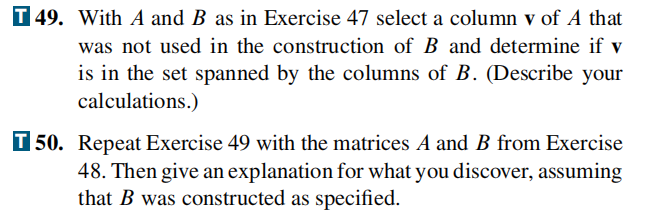

In [43]:
# 习题49：基于习题47
all_cols47 = set(range(A47.shape[1]))
unused_cols47 = all_cols47 - set(pivot_cols47)
print(f"未被用于构造B47的列: {[c+1 for c in unused_cols47]}")

# 检查是否在B的列空间中
for col_idx in unused_cols47:
    v = A47_sym[:, col_idx] 
    print(f"\n列 {col_idx+1}:")
    print(f"v = {v}")

    # 判断v是否在B的列空间中，即Bc = v是否有解
    augmented = B47_sym.row_join(v)
    rank_B = B47_sym.rank()
    rank_aug = augmented.rank()

    if rank_B == rank_aug:
        print(f"列 {col_idx+1} 在B的列空间中。")
        c = B47_sym.solve(v)
        print(f"一个解为c = {c}")
    else:
        print(f"列 {col_idx+1} 不在B的列空间中。")


未被用于构造B47的列: [3, 4]

列 3:
v = Matrix([[0], [5], [2], [7]])
列 3 在B的列空间中。
一个解为c = Matrix([[3], [8], [0]])

列 4:
v = Matrix([[-7], [11], [-4], [0]])
列 4 在B的列空间中。
一个解为c = Matrix([[1], [5], [0]])


计算过程：易知未被使用的向量为第3和4列，要判断**v**是否在$B$的列空间中，即判断方程组
$$
B\mathbf{c} = \mathbf{v}
$$
是否有解，即判断$B$的秩和增广矩阵[B|v]的秩是否相等，相等即有非零解，可说明**v**在$B$的列空间中。

In [44]:
# 习题50：基于习题48
all_cols48 = set(range(A48.shape[1]))
unused_cols48 = all_cols48 - set(pivot_cols48)
print(f"未被用于构造B48的列: {[c+1 for c in unused_cols48]}")

for col_idx in unused_cols48:
    v = A48_sym[:, col_idx]
    print(f"\n检查列 {col_idx+1}:")
    print(f"v = {v}")

    augmented = B48_sym.row_join(v)
    rank_B = B48_sym.rank()
    rank_aug = augmented.rank()

    if rank_B == rank_aug:
        print(f"列 {col_idx+1} 在 B 的列空间中。")
        c = B48_sym.solve(v)
        print(f"一个解为c = {c}")
    else:
        print(f"列 {col_idx+1} 不在 B 的列空间中。")

未被用于构造B48的列: [3, 5]

检查列 3:
v = Matrix([[-6], [4], [-9], [1], [-5]])
列 3 在 B 的列空间中。
一个解为c = Matrix([[2], [-3], [0], [0]])

检查列 5:
v = Matrix([[7], [-9], [5], [-8], [11]])
列 5 在 B 的列空间中。
一个解为c = Matrix([[2], [-2], [-1], [0]])


## 1.8 Introduction to Linear Transformations

一个**变换**（或**函数**/ **映射**）$T: \mathbb{R}^n \to \mathbb{R}^m$ 是一个规则，它给 $\mathbb{R}^n$ 中的每个向量 $\mathbf{x}$ 指派 $\mathbb{R}^m$ 中的一个向量 $T(\mathbf{x})$。

**定义域（Domain）** :输入向量 $\mathbf{x}$ 所在的空间 $\mathbb{R}^n$ 

**陪域（Codomain）**:输出向量 $T(\mathbf{x})$ 所在的空间 $\mathbb{R}^m$ 

**值域（Range）**:所有可能的输出向量 $T(\mathbf{x})$ 的集合（是陪域的子集） 
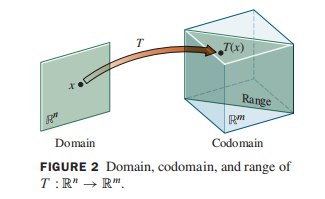


**矩阵变换（Matrix Transformation）**

定义:

如果变换 $T$ 由矩阵乘法实现，即
$$
T(\mathbf{x}) = A\mathbf{x}
$$
其中 $A$ 是 $m \times n$ 矩阵，则称 $T$ 为**矩阵变换**，记作 $\mathbf{x} \mapsto A\mathbf{x}$。

**为什么值域=列空间？**
$$
T(\mathbf{x}) = A\mathbf{x} = x_1\mathbf{a}_1 + x_2\mathbf{a}_2 + \cdots + x_n\mathbf{a}_n
$$
所以所有像正好构成 $A$ 的列空间。

**矩阵变换的线性性质**

若 $A$ 是 $m \times n$ 矩阵，则变换 $\mathbf{x} \mapsto A\mathbf{x}$ 满足：

$$
A(\mathbf{u} + \mathbf{v}) = A\mathbf{u} + A\mathbf{v}
$$

$$
A(c\mathbf{u}) = cA\mathbf{u}
$$

对任意 $\mathbf{u}, \mathbf{v} \in \mathbb{R}^n$ 和任意标量 $c$ 成立。


**定义**

变换 $T$ 称为**线性的**，如果满足以下两条：

$$
\text{(i)} \quad T(\mathbf{u} + \mathbf{v}) = T(\mathbf{u}) + T(\mathbf{v}) \quad 
$$

$$
\text{(ii)} \quad T(c\mathbf{u}) = cT(\mathbf{u}) \quad 
$$

对所有定义域中的 $\mathbf{u}, \mathbf{v}$ 和所有标量 $c$ 成立。

**线性变换的两个重要推论**

1.零向量映射到零向量
$$
T(\mathbf{0}) = \mathbf{0}
$$

2.叠加原理
$$
T(c\mathbf{u} + d\mathbf{v}) = cT(\mathbf{u}) + dT(\mathbf{v})
$$



**线性性的等价刻画**

若一个变换 $T$ 对所有 $\mathbf{u}, \mathbf{v}$ 和所有标量 $c, d$ 满足
$$
T(c\mathbf{u} + d\mathbf{v}) = cT(\mathbf{u}) + dT(\mathbf{v})
$$
则 $T$ 一定是线性变换。

**叠加原理（推广）**

对多个向量的线性组合，有：
$$
T(c_1\mathbf{v}_1 + \cdots + c_p\mathbf{v}_p) = c_1T(\mathbf{v}_1) + \cdots + c_pT(\mathbf{v}_p)
$$



### <span style="color: #3498db;">习题1.8 36
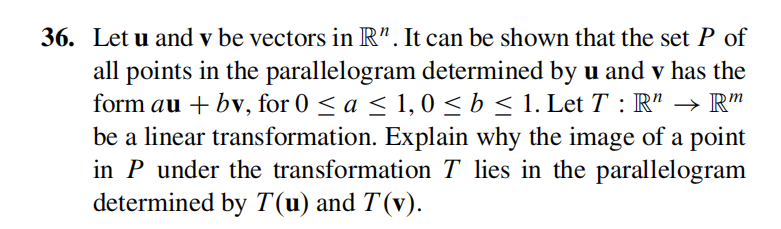

设 $P$中任意一点为  
$$
\mathbf{p}=a\mathbf{u}+b\mathbf{v},\quad 0\le a\le 1,\;0\le b\le 1.
$$  

因为 $T$ 是线性变换，它保持向量的线性组合，即  
$$
T(\mathbf{p})=T(a\mathbf{u}+b\mathbf{v})=aT(\mathbf{u})+bT(\mathbf{v}).
$$  

由于 $a,b$ 满足  
$$
0\le a\le 1,\quad 0\le b\le 1,
$$  
所以 $T(\mathbf{p})$ 恰好是由 $T(\mathbf{u})$ 和 $T(\mathbf{v})$ 作为相邻边所确定的平行四边形（其点集为 $\{aT(\mathbf{u})+bT(\mathbf{v}) \mid 0\le a\le 1,\;0\le b\le 1\}$）中的点。  

因此， $P$ 在 $T$ 下的像包含于由 $T(\mathbf{u})$ 和 $T(\mathbf{v})$ 确定的平行四边形中。


### <span style="color: #3498db;">习题1.8 38
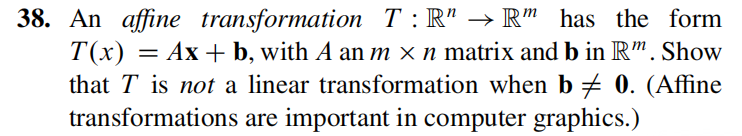


若为线性变换，则必须满足：零向量映射到零向量，即对任意线性变换 $T$，都有  
$$
T(\mathbf{0}) = \mathbf{0}.
$$
即 
$$
T(\mathbf{0}) = T(0 \cdot \mathbf{x}) = 0 \cdot T(\mathbf{x}) = \mathbf{0}.
$$

对于仿射变换 $T(\mathbf{x}) = A\mathbf{x} + \mathbf{b}$，计算零向量的像：  
$$
T(\mathbf{0}) = A \cdot \mathbf{0} + \mathbf{b} = \mathbf{0} + \mathbf{b} = \mathbf{b}.
$$

若 $\mathbf{b} \neq \mathbf{0}$，则 $T(\mathbf{0}) = \mathbf{b} \neq \mathbf{0}$，这与线性变换必须满足 $T(\mathbf{0}) = \mathbf{0}$ 矛盾。

因此，当 $\mathbf{b} \neq \mathbf{0}$ 时，仿射变换 $T$ 不是线性变换。

### <span style="color: #3498db;">习题1.8 41
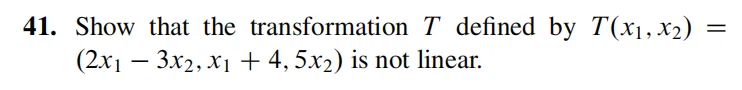


对任意线性变换 $T$，都有  
$$
T(\mathbf{0}) = \mathbf{0}.
$$

计算 $T$ 在原点处的值：
$$
T(0, 0) = (2\cdot 0 - 3\cdot 0,\ 0 + 4,\ 5\cdot 0) = (0,\ 4,\ 0).
$$

$(0, 4, 0) \neq (0, 0, 0)$，因此 $T(\mathbf{0}) \neq \mathbf{0}$，不满足线性变换的性质。

故，变换 $T$ 不是线性变换。


### <span style="color: #3498db;">习题1.8 45-48
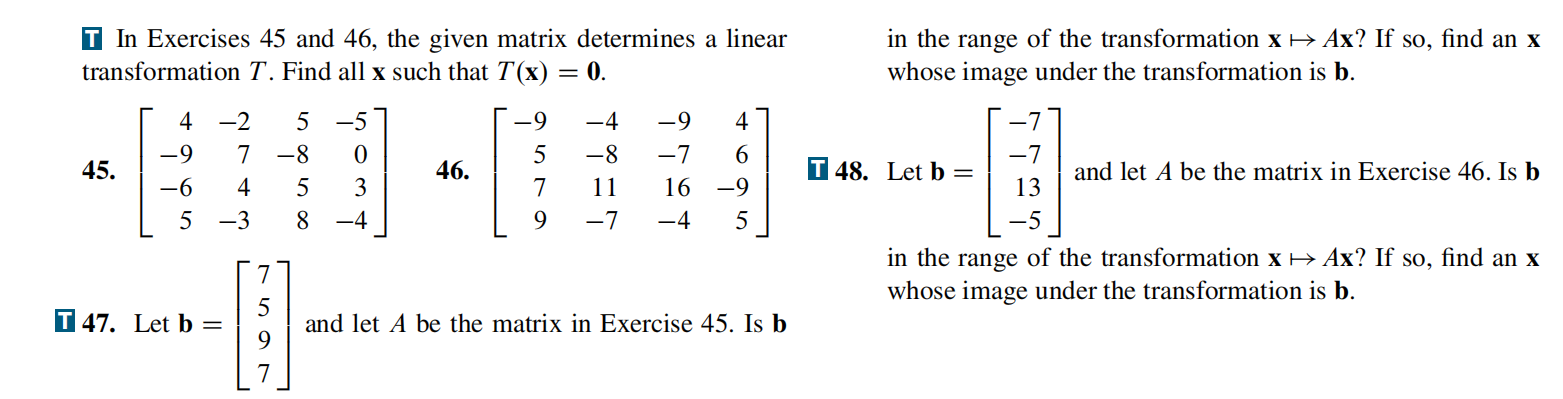

In [58]:
import sympy as sp

# 定义矩阵A45,A46
A45 = sp.Matrix([
    [4, -2, 5, -5],
    [-9, 7, -8, 0],
    [-6, 4, 5, 3],
    [5, -3, 8, -4]
])

A46 = sp.Matrix([
    [-9, -4, -9, 4],
    [5, -8, -7, 6],
    [7, 11, 16, -9],
    [9, -7, -4, 5]
])

# 定义b向量
b47 = sp.Matrix([7, 5, 9, 7])
b48 = sp.Matrix([-7, -7, 13, -5])

def solve_homogeneous(A):
    nullspace = A.nullspace()
    print("Ax = 0的通解为：")
    if not nullspace:
        print(" 只有零解")
    else:
        vars = sp.symbols('t1:%d' % (len(nullspace)+1))
        sol = sp.zeros(A.cols, 1)
        for i, vec in enumerate(nullspace):
            sol += vars[i] * vec
        print("  x =", sol)
        print("  其中", ', '.join([str(v) + " 为自由变量" for v in vars]))
    return nullspace

def solve_nonhomogeneous(A, b):
    aug = A.row_join(b)
    if A.rank() == aug.rank():
        print("方程Ax = b有解，b在列空间中。")
        n = A.cols
        x = sp.symbols('x1:%d' % (n+1))
        eqns = []
        for i in range(A.rows):
            row_expr = sum(A[i,j]*x[j] for j in range(n)) - b[i]
            eqns.append(sp.Eq(row_expr, 0))
        sol = sp.solve(eqns, x)
        if sol:
            particular = sp.Matrix([sol.get(xi, 0) for xi in x])
            print("解集为：", particular)
            x4 = sp.symbols('x4')
            particular2 = sp.Matrix([sol.get(xi, 0) for xi in x]).subs({x4: 0})
            print("一个特解为：", particular2)
            return particular
    else:
        print("方程Ax = b无解，b不在列空间中。")
        return None

# 习题45
print("-"*50)
print("习题45：求Ax = 0的解集")
solve_homogeneous(A45)

# 习题46
print("\n" + "-"*50)
print("习题46：求Ax = 0的解集")
solve_homogeneous(A46)

# 习题47
print("\n" + "-"*50)
print("习题47：b =", b47)
solve_nonhomogeneous(A45, b47)

# 习题48
print("\n" + "-"*50)
print("习题48：b =", b48)
solve_nonhomogeneous(A46, b48);

--------------------------------------------------
习题45：求Ax = 0的解集
Ax = 0的通解为：
  x = Matrix([[7*t1/2], [9*t1/2], [0], [t1]])
  其中 t1 为自由变量

--------------------------------------------------
习题46：求Ax = 0的解集
Ax = 0的通解为：
  x = Matrix([[-3*t1/4], [-5*t1/4], [7*t1/4], [t1]])
  其中 t1 为自由变量

--------------------------------------------------
习题47：b = Matrix([[7], [5], [9], [7]])
方程Ax = b有解，b在列空间中。
解集为： Matrix([[7*x4/2 + 4], [9*x4/2 + 7], [1], [0]])
一个特解为： Matrix([[4], [7], [1], [0]])

--------------------------------------------------
习题48：b = Matrix([[-7], [-7], [13], [-5]])
方程Ax = b有解，b在列空间中。
解集为： Matrix([[-3*x4/4 - 5/4], [-5*x4/4 - 11/4], [7*x4/4 + 13/4], [0]])
一个特解为： Matrix([[-5/4], [-11/4], [13/4], [0]])


## 1.9 The Matrix of a Linear Transformation


每个线性变换 $T:\mathbb{R}^n \to \mathbb{R}^m$ 都对应一个唯一的矩阵 $A$，称为**标准矩阵**，使得  
$$
T(\mathbf{x}) = A\mathbf{x}.
$$

**标准矩阵的构造**
$A$ 的第 $j$ 列为 $T(\mathbf{e}_j)$，其中 $\mathbf{e}_j$ 是单位矩阵的第 $j$ 列：  
$$
A = \begin{bmatrix} T(\mathbf{e}_1) & T(\mathbf{e}_2) & \cdots & T(\mathbf{e}_n) \end{bmatrix}.
$$



**单射与满射的判定**

设 $A$ 为 $T$ 的标准矩阵，则

| 性质 | 等价条件 |
|:---|:---|
| $T$ 是单射（one-to-one） | $A$ 的列线性无关（$A\mathbf{x} = \mathbf{0}$ 只有零解） |
| $T$ 是满射（onto $\mathbb{R}^m$） | $A$ 的列张成 $\mathbb{R}^m$（每行有主元） |

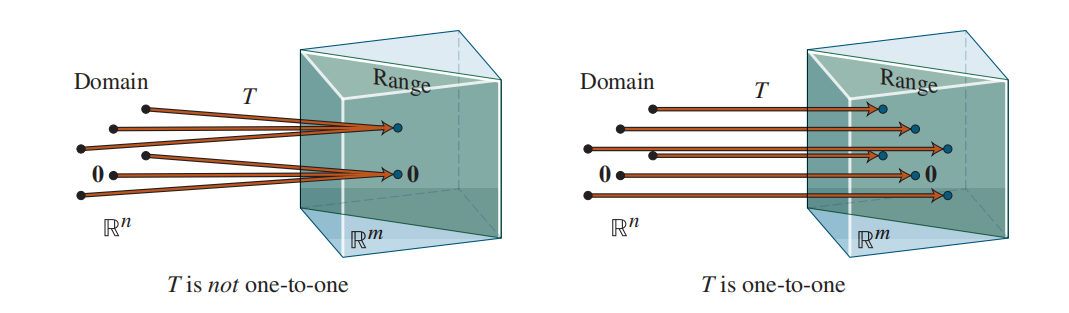
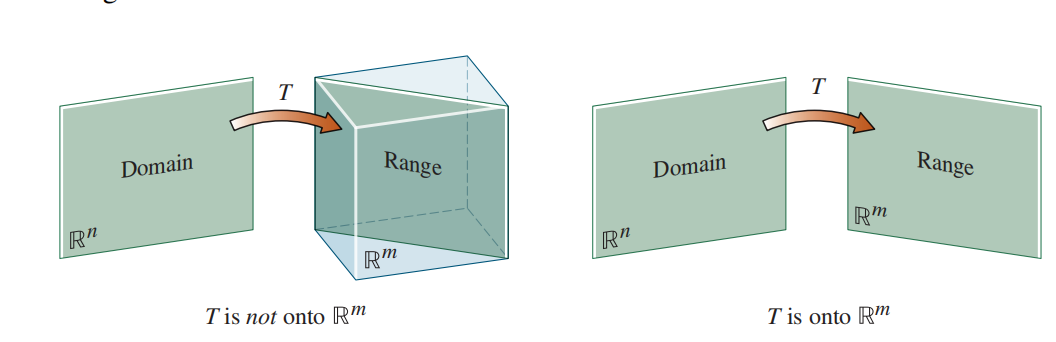



**几何变换的标准矩阵**
常见几何变换（旋转、反射、剪切、投影、伸缩）均可由标准矩阵表示。


### <span style="color: #3498db;">习题1.9 41
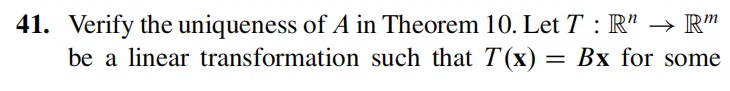
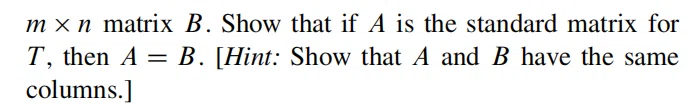

设 $\mathbf{e}_1, \mathbf{e}_2, \ldots, \mathbf{e}_n$ 是 $\mathbb{R}^n$ 中单位矩阵的列向量。

根据定义，$A$ 的第 $j$ 列为  
$$
A\mathbf{e}_j = T(\mathbf{e}_j).
$$

又因为，已知对任意 $\mathbf{x} \in \mathbb{R}^n$，有  
$$
T(\mathbf{x}) = B\mathbf{x}.
$$
取 $\mathbf{x} = \mathbf{e}_j$，则  
$$
T(\mathbf{e}_j) = B\mathbf{e}_j.
$$

因此，$A$ 的第 $j$ 列 $T(\mathbf{e}_j)$ 等于 $B$ 的第 $j$ 列 $B\mathbf{e}_j$。  
且对每个 $j = 1, 2, \ldots, n$ 都成立，所以 $A$ 与 $B$ 的所有对应列都相同，故 
$$
A = B.
$$
即证。

### <span style="color: #3498db;">习题1.9 42
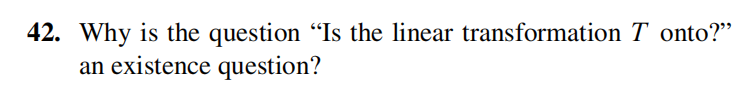


“$T$ 是否为满射”问的是：**陪域 $\mathbb{R}^m$ 中的每一个向量 $\mathbf{b}$，是否都能找到至少一个定义域中的向量 $\mathbf{x}$，使得 $T(\mathbf{x}) = \mathbf{b}$**。

也就是说，对于任意给定的 $\mathbf{b}$，方程
$$
T(\mathbf{x}) = \mathbf{b}
$$
是否**有解**。

即是否存在 $\mathbf{x}$ 满足条件，所以它是一个**存在性问题**。


### <span style="color: #3498db;">习题1.9 43
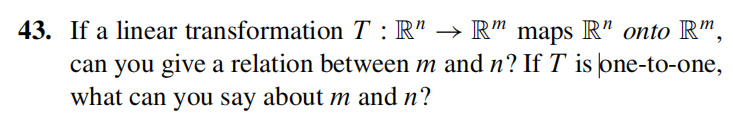


设 $A$ 为 $T$ 的标准矩阵，它是 $m \times n$ 矩阵。

**1.$T$ 是满射（onto $\mathbb{R}^m$）**

满射等价于 $A$ 的列张成 $\mathbb{R}^m$，故 $A$ 的秩等于 $m$。
但 $\operatorname{rank}(A) \leq n$。
因此必须有
$$
m = \operatorname{rank}(A) \leq n.
$$

所以满射时：  
$$
m \leq n
$$
（列数不少于行数）

**2.$T$ 是单射（one-to-one）**

单射等价于$A\mathbf{x} = \mathbf{0}$ 只有零解，因此 $A$ 的列线性无关。
线性无关的列数不能超过行数，即 $n \leq m$

等价于 $\operatorname{rank}(A) = n$，且 $n \leq m$。

所以单射时：  
$$
n \leq m
$$
（行数不少于列数）

| 条件 | 维度关系 |
|:---:|:---:|
| $T$ 是满射（onto） | $m \leq n$ |
| $T$ 是单射（one-to-one） | $n \leq m$ |
| $T$ 既是单射又是满射（即同构） | $m = n$（方阵且可逆） |


### <span style="color: #3498db;">习题1.9 44
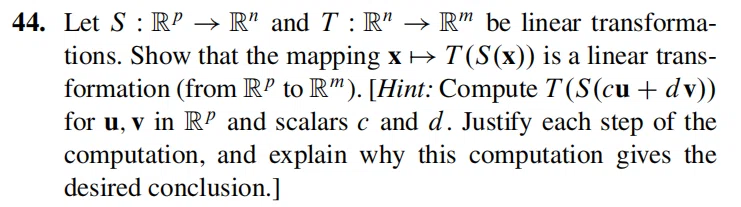


要证明映射 $\mathbf{x} \mapsto T(S(\mathbf{x}))$ 是线性的，只需验证它满足线性变换的两个条件：可加性与齐次性。即验证它对任意线性组合成立：
$$
T(S(c\mathbf{u} + d\mathbf{v})) = c\,T(S(\mathbf{u})) + d\,T(S(\mathbf{v})).
$$

设 $\mathbf{u}, \mathbf{v} \in \mathbb{R}^p$，$c, d$ 为任意标量。

由于 $S$ 是线性变换，它满足：
   $$
   S(c\mathbf{u} + d\mathbf{v}) = cS(\mathbf{u}) + dS(\mathbf{v}).
   $$

令 $\mathbf{a} = S(\mathbf{u})$，$\mathbf{b} = S(\mathbf{v})$，则上式变为
   $$
   S(c\mathbf{u} + d\mathbf{v}) = c\mathbf{a} + d\mathbf{b}.
   $$

由于 $T$ 是线性变换，它对 $\mathbb{R}^n$ 中的任意向量也保持线性组合：
   $$
   T(c\mathbf{a} + d\mathbf{b}) = cT(\mathbf{a}) + dT(\mathbf{b}).
   $$

代回 $\mathbf{a} = S(\mathbf{u})$，$\mathbf{b} = S(\mathbf{v})$：
   $$
   T(S(c\mathbf{u} + d\mathbf{v})) = cT(S(\mathbf{u})) + dT(S(\mathbf{v})).
   $$
即证。

### <span style="color: #3498db;">习题1.9 45-48
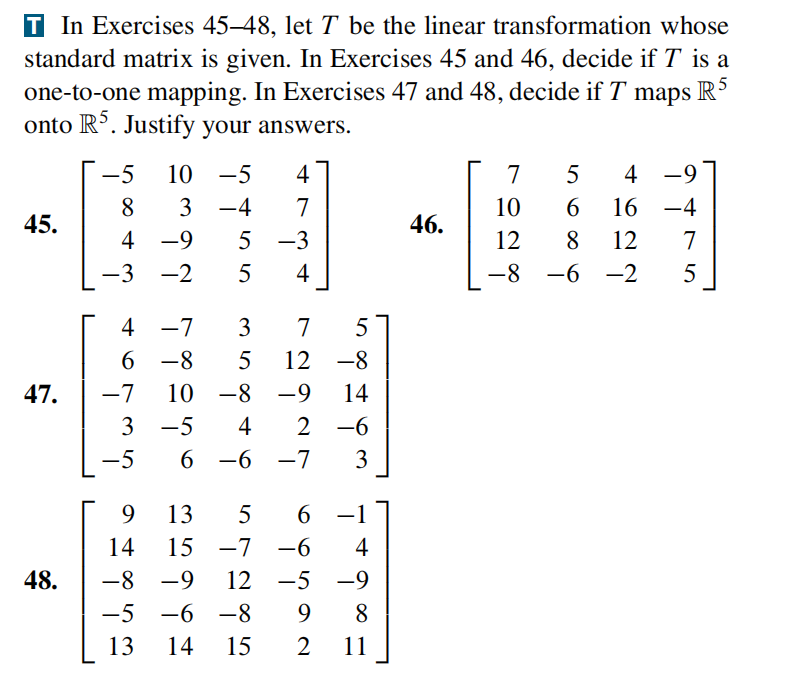

In [ ]:
# 定义矩阵
matrices = {
    "45": np.array([
        [-5, 10, -5, 4],
        [8, 3, -4, 7],
        [4, -9, 5, -3],
        [-3, -2, 5, 4]
    ]),
    "46": np.array([
        [7, 5, 4, -9],
        [10, 6, 16, -4],
        [12, 8, 12, 7],
        [-8, -6, -2, 5]
    ]),
    "47": np.array([
        [4, -7, 3, 7, 5],
        [6, -8, 5, 12, -8],
        [-7, 10, -8, -9, 14],
        [3, -5, 4, 2, -6],
        [-5, 6, -6, -7, 3]
    ]),
    "48": np.array([
        [9, 13, 5, 6, -1],
        [14, 15, -7, -6, 4],
        [-8, -9, 12, -5, -9],
        [-5, -6, -8, 9, 8],
        [13, 14, 15, 2, 11]
    ])
}

for key, A in matrices.items():
    rank = np.linalg.matrix_rank(A)
    rows, cols = A.shape
    print(f"矩阵 {key}: 形状 {rows}x{cols}, 秩 = {rank}")
    
    if key in ["45", "46"]:
        # 单射等价于列满秩
        is_one_to_one = (rank == cols)
        print(f"  T 是单射? {'是' if is_one_to_one else '否'}")
    elif key in ["47", "48"]:
        # 满射到 R^5等价于秩为5
        is_onto = (rank == rows)  # rows = 5
        print(f"  T 映射 R^5 到 R^5 上? {'是' if is_onto else '否'}")
    print()

矩阵 45: 形状 4x4, 秩 = 3
  T 是单射? 否

矩阵 46: 形状 4x4, 秩 = 3
  T 是单射? 否

矩阵 47: 形状 5x5, 秩 = 4
  T 映射 R^5 到 R^5 上? 否

矩阵 48: 形状 5x5, 秩 = 4
  T 映射 R^5 到 R^5 上? 否



矩阵45、46，单射等价于列满秩，故计算其秩的大小是否等于列数。

矩阵47、48，满射到 $\mathbb{R}^5$ 等价于秩为5,故计算其秩是否等于5.


## 1.10 线性模型的应用

一些实际问题可用线性模型表示和求解，这些模型的共同点是**线性性**：
- 总量 = 各部分之和（叠加原理）
- 输出与输入成比例（齐次性）



### <span style="color: #3498db;">习题1.10 6
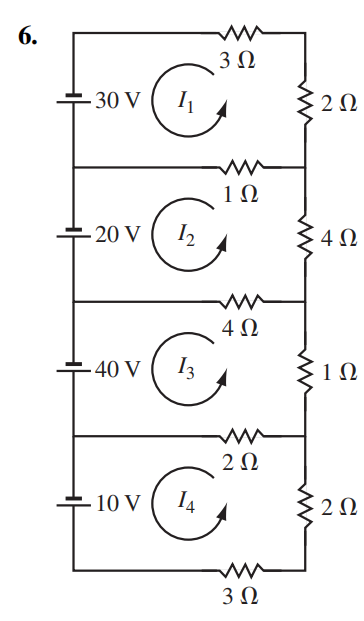


分析题图可得

$$
\begin{cases}
6I_1 - I_2 = 30 \\
-I_1 + 9I_2 - 4I_3 = 20 \\
-4I_2 + 7I_3 - 2I_4 = 40 \\
-2I_3 + 7I_4=10
\end{cases}
$$

设未知向量
$\mathbf{x}= \begin{bmatrix}I_1 \\ I_2 \\ I_3 \\ I_4 \end{bmatrix}$

系数矩阵
$$A = 
\begin{bmatrix}
6 & -1 & 0 & 0 \\
-1 & 9 &-4 & 0 \\
0 &-4 & 7 & -2 \\
0 & 0 & -2 & 7
\end{bmatrix}
\quad
\mathbf{b} = \begin{bmatrix} 30 \\ 20 \\ 40 \\ 10 \end{bmatrix}.
$$
 构造增广矩阵 $[A \mid \mathbf{b}]$
$$
\left[\begin{array}{cccc|c}
6 & -1 & 0 & 0 & 30 \\
-1 & 9 & -4 & 0 & 20 \\
0 & -4 & 7 & -2 & 40 \\
0 & 0 & -2 & 7 & 10
\end{array}\right]
$$
利用代码求解如下：


In [60]:
I1, I2, I3, I4 = sp.symbols('I1 I2 I3 I4')

# 定义方程组
eq1 = sp.Eq(6*I1 - I2, 30)
eq2 = sp.Eq(-I1 + 9*I2 - 4*I3, 20)
eq3 = sp.Eq(-4*I2 + 7*I3 - 2*I4, 40)
eq4 = sp.Eq(-2*I3 + 7*I4, 10)

# 求解
sol = sp.solve((eq1, eq2, eq3, eq4), (I1, I2, I3, I4))

print("解为：")
for var, val in sol.items():
    print(f"{var} = {val}  ≈ {val.evalf():.6f}")

解为：
I1 = 3630/571  ≈ 6.357268
I2 = 4650/571  ≈ 8.143608
I3 = 6700/571  ≈ 11.733800
I4 = 2730/571  ≈ 4.781086


### <span style="color: #3498db;">习题1.10 8
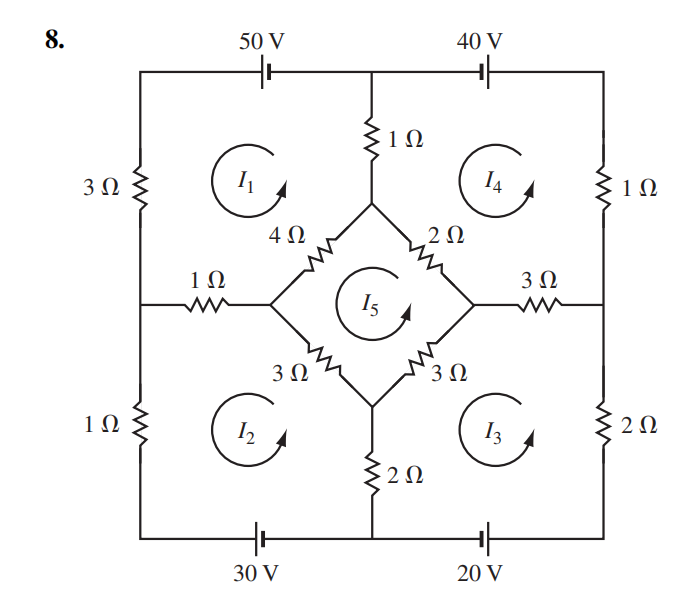


分析题图可得

$$
\begin{cases}
9I_1 - I_2 - I_4 - 4I_5 = 50 \\
-I_1 + 7I_2 - 2I_3 -3I_5 = -30 \\
-2I_2 + 10I_3 - 3I_4 -3I_5 = 20 \\
-I_1 - 3I_3 + 7I_4 - 2I_5 = -40 \\
-4I_1 - 3I_2 -3I_3-2I_4 + 12I_5 = 0
\end{cases}
$$

设未知向量
$\mathbf{x}= \begin{bmatrix}I_1 \\ I_2 \\ I_3 \\ I_4 \\I_5 \end{bmatrix}$

系数矩阵
$$A = 
\begin{bmatrix}
9 & -1 & 0 & -1 & -4 \\
-1 & 7 & -2 & 0 & -3 \\
0 & -2 & 10 & -3 & -3 \\
-1 & 0 & -3 & 7 & -2 \\
-4 & -3 & -3 & -2 & 12
\end{bmatrix}
\quad
\mathbf{b} = \begin{bmatrix} 50 \\ -30 \\ 20 \\ -40 \\ 0 \end{bmatrix}.
$$
 构造增广矩阵 $[A \mid \mathbf{b}]$
$$
\left[\begin{array}{ccccc|c}
9 & -1 & 0 & -1 & -4 & 50 \\
-1 & 7 & -2 & 0 & -3 & -30 \\
0 & -2 & 10 & -3 & -3 & 20 \\
-1 & 0 & -3 & 7 & -2 & -40 \\
-4 & -3 & -3 & -2 & 12 & 0
\end{array}\right]
$$
利用代码求解如下：


In [63]:
I1, I2, I3, I4, I5 = sp.symbols('I1 I2 I3 I4 I5')

# 定义方程组
eq1 = sp.Eq(9*I1 - I2 - I4 - 4*I5, 50)
eq2 = sp.Eq(-I1 + 7*I2 - 2*I3 - 3*I5, -30)
eq3 = sp.Eq(-2*I2 + 10*I3 - 3*I4 - 3*I5, 20)
eq4 = sp.Eq(-I1 - 3*I3 + 7*I4 - 2*I5, -40)
eq5 = sp.Eq(-4*I1 - 3*I2 - 3*I3 - 2*I4 + 12*I5, 0)

# 求解
sol = sp.solve((eq1, eq2, eq3, eq4, eq5), (I1, I2, I3, I4, I5))

# 输出结果
print("解为：")
for var, val in sol.items():
    print(f"{var} = {val}  ≈ {val.evalf():.6f}")

解为：
I1 = 3019/755  ≈ 3.998675
I2 = -3309/755  ≈ -4.382781
I3 = -683/755  ≈ -0.904636
I4 = -4382/755  ≈ -5.803974
I5 = -722/755  ≈ -0.956291


### <span style="color: #3498db;">习题1.10 12
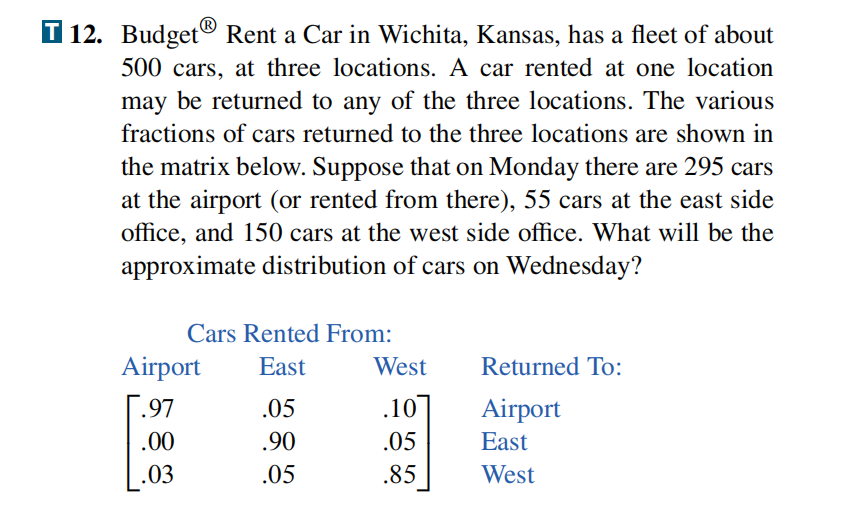


In [64]:
M12 = np.array([
    [0.97, 0.05, 0.10],   # 归还至机场
    [0.00, 0.90, 0.05],   # 归还至东区
    [0.03, 0.05, 0.85]    # 归还至西区
])

# 周一初始分布
x0_12 = np.array([295, 55, 150])

# 周三，即M^2*x0
x2 = np.linalg.matrix_power(M12, 2) @ x0_12

print("周三汽车分布（约）")
print(f"机场: {x2[0]:.1f} 辆")
print(f"东区: {x2[1]:.1f} 辆")
print(f"西区: {x2[2]:.1f} 辆")
print(f"总数: {x2.sum():.1f}\n")


周三汽车分布（约）
机场: 311.5 辆
东区: 58.3 辆
西区: 130.2 辆
总数: 500.0



### <span style="color: #3498db;">习题1.10 13
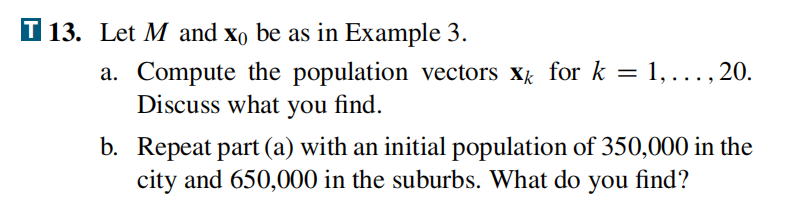

In [67]:
# 例3的迁移矩阵 M = [[0.95, 0.03], [0.05, 0.97]]
M13 = np.array([
    [0.95, 0.03],
    [0.05, 0.97]
])

def print_population(x0, label):
    print(f"\n{label}")
    for k in range(21):  # 计算 k=0 到 20
        xk = np.linalg.matrix_power(M13, k) @ x0
        print(f"k={k:2d}: 城市 {xk[0]:8.0f}, 郊区 {xk[1]:8.0f}")

#(a) 初始人口 600k（城市），400k（郊区）
x0_13a = np.array([600000, 400000])
print_population(x0_13a, "(a) 初始 (600k, 400k)")



(a) 初始 (600k, 400k)
k= 0: 城市   600000, 郊区   400000
k= 1: 城市   582000, 郊区   418000
k= 2: 城市   565440, 郊区   434560
k= 3: 城市   550205, 郊区   449795
k= 4: 城市   536188, 郊区   463812
k= 5: 城市   523293, 郊区   476707
k= 6: 城市   511430, 郊区   488570
k= 7: 城市   500515, 郊区   499485
k= 8: 城市   490474, 郊区   509526
k= 9: 城市   481236, 郊区   518764
k=10: 城市   472737, 郊区   527263
k=11: 城市   464918, 郊区   535082
k=12: 城市   457725, 郊区   542275
k=13: 城市   451107, 郊区   548893
k=14: 城市   445018, 郊区   554982
k=15: 城市   439417, 郊区   560583
k=16: 城市   434264, 郊区   565736
k=17: 城市   429522, 郊区   570478
k=18: 城市   425161, 郊区   574839
k=19: 城市   421148, 郊区   578852
k=20: 城市   417456, 郊区   582544


发现：

城市人口呈逐年下降趋势，郊区人口呈逐年上升趋势。

初期变化较快，随着时间推移，变化幅度逐渐减小。

In [68]:
#(b) 初始人口350k（城市），650k（郊区）
x0_13b = np.array([350000, 650000])
print_population(x0_13b, "(b) 初始 (350k, 650k)")


(b) 初始 (350k, 650k)
k= 0: 城市   350000, 郊区   650000
k= 1: 城市   352000, 郊区   648000
k= 2: 城市   353840, 郊区   646160
k= 3: 城市   355533, 郊区   644467
k= 4: 城市   357090, 郊区   642910
k= 5: 城市   358523, 郊区   641477
k= 6: 城市   359841, 郊区   640159
k= 7: 城市   361054, 郊区   638946
k= 8: 城市   362170, 郊区   637830
k= 9: 城市   363196, 郊区   636804
k=10: 城市   364140, 郊区   635860
k=11: 城市   365009, 郊区   634991
k=12: 城市   365808, 郊区   634192
k=13: 城市   366544, 郊区   633456
k=14: 城市   367220, 郊区   632780
k=15: 城市   367843, 郊区   632157
k=16: 城市   368415, 郊区   631585
k=17: 城市   368942, 郊区   631058
k=18: 城市   369427, 郊区   630573
k=19: 城市   369872, 郊区   630128
k=20: 城市   370283, 郊区   629717


发现：

城市人口呈逐年上升趋势，郊区人口呈逐年下降趋势。

初期变化较慢，但人口逐渐从郊区回流到城市。

无论初始城市人口多少，经过足够多年后，分布都趋近于一个固定数值。